<a href="https://colab.research.google.com/github/MaryamAmjad2/PyTorch/blob/main/02_2_MultiClass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sklearn
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

device='cuda' if torch.cuda.is_available() else 'cpu'

#1. Creating Toy Dataset

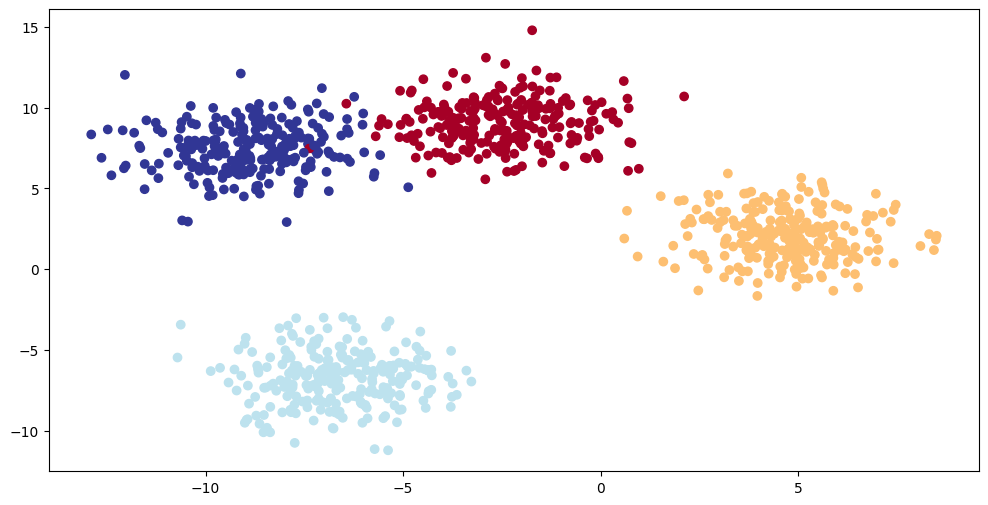

In [ ]:
# Set Hyperparamters
NUM_CLASSES=4
NUM_FETURES=2
RANDOM_SEED=42

# Create Data
X_blob, y_blob = make_blobs(n_samples=1000,
                         n_features=NUM_FETURES,
                         centers=NUM_CLASSES,
                         cluster_std=1.5,
                         random_state=RANDOM_SEED
                         )

# 2 . Turn Data into Tensor
# type(X_blob)
X_blob=torch.from_numpy(X_blob).type(torch.float32)
y_blob=torch.from_numpy(y_blob).type(torch.LongTensor)  # for CrossEntropyLoss  cz it only work with intlong
type(X_blob)

# 3. Split Train Test
X_blob_train, X_blob_test, y_blob_train, y_blob_test=train_test_split(X_blob,y_blob,
                                                                      test_size=0.2,
                                                                      random_state=RANDOM_SEED)


# 4. Plot Data
plt.figure(figsize=(12,6))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)



# 2. Building Model

In [ ]:
class BlobModel(nn.Module):
  def __init__(self,input_features,output_features,hidden_units=8):
    super().__init__()
    self.linear_layer_stack=nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        # nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        # nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)
    )
  def forward(self,x):
    return self.linear_layer_stack(x)

model_4=BlobModel(2,4).to(device)
model_4


BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

# 3. Loss and Optimizer

In [ ]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_4.parameters(),
                          lr=0.1)

In [ ]:
X_blob_train, X_blob_test = X_blob_train.to(device), X_blob_test.to(device)
y_blob_train, y_blob_test = y_blob_train.to(device), y_blob_test.to(device)

In [ ]:
model_4.eval()
with torch.inference_mode():
  y_logits=model_4(X_blob_test)
#print(y_logits[:3])

# Turn Logits -> Predictions -> Labels
y_pred_prob=torch.softmax(y_logits,dim=1)
y_pred_prob[:3]
y_preds=torch.argmax(y_pred_prob, dim=1)
print(y_preds)


tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2,
        2, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 2, 1, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 1, 3, 2, 3, 1, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 3, 3, 2, 3, 3, 3, 3, 2, 3, 1, 3, 3, 2, 1, 1, 3, 2, 2, 3, 3, 3, 1, 2,
        2, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 1, 1, 3, 2, 2,
        2, 2, 3, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3,
        2, 2, 2, 3, 3, 1, 1, 1, 1, 1, 3, 1, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        1, 3, 2, 3, 3, 1, 2, 3], device='cuda:0')


# 4. Train

In [ ]:
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct)/len(y_pred)*100
  return acc

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs=100
for epoch in range(epochs):
  model_4.train()
  y_logits=model_4(X_blob_train)
  y_pred=torch.softmax(y_logits,dim=1).argmax(dim=1)

  loss=loss_fn(y_logits,y_blob_train)
  acc=accuracy_fn(y_blob_train,y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


  model_4.eval()
  with torch.inference_mode():
    y_test_logits=model_4(X_blob_test)
    y_test_pred_prob=torch.softmax(y_test_logits,dim=1).argmax(dim=1)
    test_loss=loss_fn(y_test_logits,y_blob_test)
    test_acc=accuracy_fn(y_blob_test,y_test_pred_prob)

  if epoch%10==0:
    print(f'Train loss {loss.item():.5f} | Test loss {test_loss.item():.5f} |  Train Accuracy {acc:.3f} | Test Accuracy {test_acc:.3f}')

Train loss 1.04324 | Test loss 0.57861 |  Train Accuracy 65.500 | Test Accuracy 95.500
Train loss 0.14398 | Test loss 0.13037 |  Train Accuracy 99.125 | Test Accuracy 99.000
Train loss 0.08062 | Test loss 0.07216 |  Train Accuracy 99.125 | Test Accuracy 99.500
Train loss 0.05924 | Test loss 0.05133 |  Train Accuracy 99.125 | Test Accuracy 99.500
Train loss 0.04892 | Test loss 0.04098 |  Train Accuracy 99.000 | Test Accuracy 99.500
Train loss 0.04295 | Test loss 0.03486 |  Train Accuracy 99.000 | Test Accuracy 99.500
Train loss 0.03910 | Test loss 0.03083 |  Train Accuracy 99.000 | Test Accuracy 99.500
Train loss 0.03643 | Test loss 0.02799 |  Train Accuracy 99.000 | Test Accuracy 99.500
Train loss 0.03448 | Test loss 0.02587 |  Train Accuracy 99.000 | Test Accuracy 99.500
Train loss 0.03300 | Test loss 0.02423 |  Train Accuracy 99.125 | Test Accuracy 99.500


# 5. Visualize

## Import Helper Function

In [ ]:
import requests
from pathlib import Path

# Download Helper Function
if Path('helper_function.py').is_file():
  print("Yes")
else:
  print("Downloading ")
  request=requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
  with open('helper_function.py','wb') as f:
    f.write(request.content)

from helper_function import plot_predictions, plot_decision_boundary

Yes


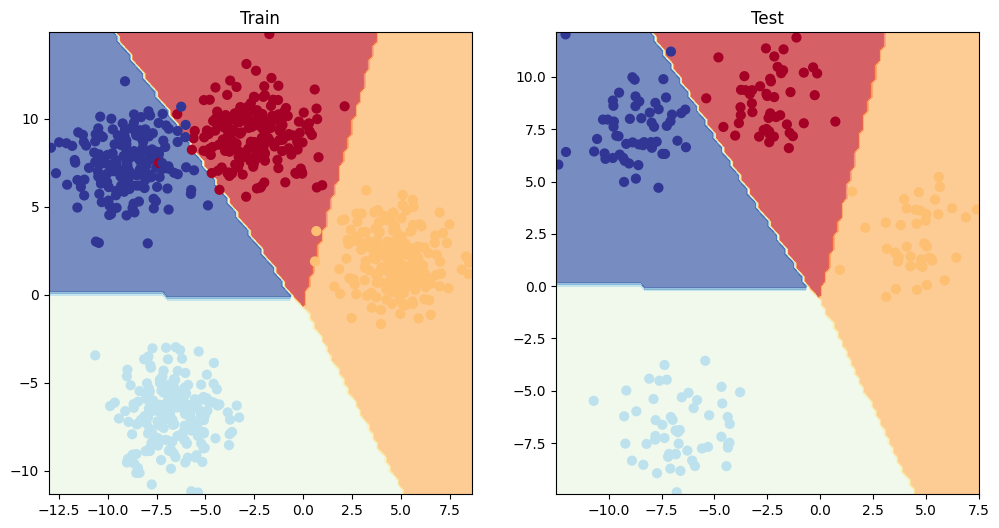

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4,X_blob_train,y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4,X_blob_test,y_blob_test)

# 6. Evaluation Metrices



1.   Accuracy
2.   Precision


1.   Recall
2.   F1 Score


1.   Confusion Matrix
2.   Classification Report







In [ ]:
from torchmetrics import Accuracy,Recall

torchmetric_acc= Accuracy(task='MULTICLASS', num_classes=NUM_CLASSES).to(device)
print(torchmetric_acc(y_test_pred_prob,y_blob_test))

torch_recall=Recall(task='MULTICLASS', num_classes=NUM_CLASSES).to(device)
print(torch_recall(y_test_pred_prob,y_blob_test))

tensor(0.9950, device='cuda:0')
tensor(0.9950, device='cuda:0')
